# Assignment 2

## Group 7

Benjamin Heuschmid, Farooq Khan and Taha Sekerci

## 1. Introduction

Rapid consumption of fossil fuels causes major economic, energy and environmental issues worldwide. It also causes the greenhouse effect by the release of CO<sub>2</sub> into the atmosphere. CH<sub>3</sub>OCH<sub>3</sub> (DME) is a clean burning fuel substitute and chemical raw material for many processes and is also a promising way to utilize CO<sub>2</sub> in the atmosphere [1]. For the given reasons this study focuses on direct synthesis of DME from a syngas (mixture of CO, CO<sub>2</sub> and H<sub>2</sub>) to obtain useful fuel and raw material from atmospheric CO<sub>2</sub>.

$$CO_2 + 3H_2 \rightleftharpoons CH_3OH + H_2O \qquad \text{(Methanol synthesis from } CO_2\text{)} \tag{R1}$$

$$CO + 2H_2 \rightleftharpoons CH_3OH \qquad \text{(Methanol synthesis from CO)} \tag{R2}$$

$$CO_2 + H_2 \rightleftharpoons CO + H_2O \qquad \text{(reverse Water Gas Shift reaction)} \tag{R3}$$

$$2CH_3OH \rightleftharpoons CH_3OCH_3 + H_2O \qquad \text{(Methanol dehydration to Dimethyl Ether)} \tag{R4}$$

The reaction set consists of three exothermic (R1, R2 and R4) and one endothermic reaction (R3). Also R1, R2 and R3 are thermodynamically interconnected where overall methanol (CH<sub>3</sub>OH) production happens to be finally used in R4 to produce DME [2].

In general, the reaction set is sensitive to many factors such as operating temperature, pressure or composition of the feed. Conventional production processes with the given reaction set consist of two separate steps: first, syngas converted to methanol by utilizing Cu based catalyst and after dehydrating the obtained methanol. As a second step DME is obtained by utilizing γ Al<sub>2</sub>O<sub>3</sub> catalyst [2]. The task for this assignment is to investigate the equilibrium yield of DME. For this study databases of NIST for CO<sub>2</sub>, CO, H<sub>2</sub>O, H<sub>2</sub> and CoolProp for CH<sub>3</sub>OH, CH<sub>3</sub>OCH<sub>3</sub> are used.

A valuable output could be obtained as a result of this assignment in the means of testing suitable operating conditions to check for conversion ratio and yield of the desired product (DME in this study). Understanding the equilibrium yield and conversion ratio with different temperatures, pressures and feed composition ratios can help with a better analysis of the product composition and further development of efficient processes.

The direct synthesis of DME from syngas by using methanol as an intermediate is a promising approach to the power-to-X concept, which involves the storage of renewable electrical energy in the form of hydrogen or syngas [2].
Operating conditions are set according to the literature research carried out at the start of the study. An ideal temperature range of 250 – 270 °C was selected since at temperatures below 240°C methanol synthesis is too slow and at over 280°C Cu based catalyst gets damaged [3,4]. Any temperature above 300 °C also could favor the coke formation. For the pressure an ideal operating window of 40-50 bar is selected since higher pressure favors the direct synthesis concept.

<div align="center">
Table 1. Enthalpy of Reactions

| Reaction | ΔH |
| :--- | :--- |
| Methanol Synthesis from CO₂ | -49.5 kJ/mol |
| Methanol Synthesis from CO | -91 kJ/mol |
| reverse Water Gas Shift (rWGS) | 41.2 kJ/mol |
| Methanol Dehydration to Dimethyl Ether | -23.5 kJ/mol |

</div>

In [1]:
# IMPORTS
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from CoolProp.CoolProp import PropsSI
from numpy.linalg import matrix_rank
from scipy.optimize import fsolve, root
from mpl_toolkits.mplot3d import Axes3D

## 2. Stoichiometric Matrix and Key Components

## 2.1 Stoichiometric reaction system

The components are arranged in the following order:

$CO_2$, $H_2$, $CH_3OH$, $H_2O$, $CO$, $CH_3OCH_3$


The stoichiometric matrix N is written with components in rows and reactions in columns:

\begin{equation}
  {N}=
    \begin{bmatrix}
             & R_1 & R_2 & R_3 & R_4 \\
    CO_2     &  -1 &  0  & -1  &  0  \\
    H_2      &  -3 & -2  & -1  &  0  \\
    CH_3OH   &   1 &  1  &  0  & -2  \\
    H_2O     &   1 &  0  &  1  &  1  \\
    CO       &   0 & -1  &  1  &  0  \\
    CH_3OCH_3&   0 &  0  &  0  &  1
    \end{bmatrix}
  \tag{M1}
\end{equation}

The rank of this matrix determines the number of independent/key reactions. 

In [ ]:
# STOICHIOMETRIC ANALYSIS

# Define components and reactions
components = np.array(["CO2", "H2", "CH3OH", "H2O", "CO", "DME"])

reactions = np.array([
    "R1: CO2 + 3H2 -> CH3OH + H2O",
    "R2: CO + 2H2 -> CH3OH",
    "R3: CO2 + H2 -> CO + H2O",
    "R4: 2CH3OH -> DME + H2O"
])

# Stoichiometric matrix (rows = components, columns = reactions)
N_stoich = np.array([
    [-1,  0, -1,  0],   # CO2
    [-3, -2, -1,  0],   # H2
    [ 1,  1,  0, -2],   # CH3OH
    [ 1,  0,  1,  1],   # H2O
    [ 0, -1,  1,  0],   # CO
    [ 0,  0,  0,  1]    # DME
], dtype=float)

print("\nStoichiometric matrix N:")
print(N_stoich)

# Check rank and linear dependency
rank_N = matrix_rank(N_stoich)
print(f"\nRank of stoichiometric matrix: {rank_N}")
print(f"\nR3 = R1 - R2? {np.allclose(N_stoich[:, 2], N_stoich[:, 0] - N_stoich[:, 1])}")

# Define key reactions and key components
key_reaction_idx = [0, 1, 3]     # R1, R2, R4 (independent)
key_component_idx = [0, 4, 5]    # CO2, CO, DME

# Extract reduced matrix N11 and independent matrix N_independent
N11 = N_stoich[np.ix_(key_component_idx, key_reaction_idx)]
N_independent = N_stoich[:, key_reaction_idx]

print(f"\nKey reactions: {reactions[key_reaction_idx]}")
print(f"Key components: {components[key_component_idx]}")
print(f"\nReduced matrix N11:\n{N11}")
print(f"Rank of N11: {matrix_rank(N11)}")
print(f"\nKey reactions are valid: {matrix_rank(N11) == rank_N}")

# Verify atom balance
atom_matrix = np.array([
    [1, 0, 1, 0, 1, 2],   # Carbon
    [0, 2, 4, 2, 0, 6],   # Hydrogen
    [2, 0, 1, 1, 1, 1]    # Oxygen
], dtype=float)

atom_balance = atom_matrix @ N_stoich
print(f"\nAtom balance satisfied: {np.allclose(atom_balance, 0)}")


Stoichiometric matrix N:
[[-1.  0. -1.  0.]
 [-3. -2. -1.  0.]
 [ 1.  1.  0. -2.]
 [ 1.  0.  1.  1.]
 [ 0. -1.  1.  0.]
 [ 0.  0.  0.  1.]]

Rank of stoichiometric matrix: 3

R3 = R1 - R2? True

Key reactions: ['R1: CO2 + 3H2 -> CH3OH + H2O' 'R2: CO + 2H2 -> CH3OH'
 'R4: 2CH3OH -> DME + H2O']
Key components: ['CO2' 'CO' 'DME']

Reduced matrix N11:
[[-1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0.  1.]]
Rank of N11: 3

Key reactions are valid: True

Atom balance satisfied: True


### 2.2 Discussion of Matrix Rank and Key Components

The rank of the stoichiometric matrix is calculated as:

$$
R_N = 3
$$

This means that although four reactions are given, only three independent reactions are needed to describe the stoichiometric behaviour of the system. The code also verifies that:

$$
R_3 = R_1 - R_2
$$

Therefore, the reverse water-gas shift reaction $R_3$ is stoichiometrically dependent on $R_1$ and $R_2$.

The selected independent reactions are:

$$
R_1,\ R_2,\ R_4
$$

The selected key components are:

$$
CO_2,\ CO,\ DME
$$

This is a practical choice because CO<sub>2</sub> and CO are carbon-containing reactants, while DME is the desired product. The reduced matrix $N_{11}$ has the same rank as the full stoichiometric matrix, confirming that the selected key components and key reactions are valid.

The atom balance check confirms that carbon, hydrogen and oxygen atoms are conserved in all reactions. This provides a useful verification of the stoichiometric matrix before using it in reaction extent and equilibrium calculations.

## 3. Thermodynamic Properties

Thermodynamic properties are required to calculate the equilibrium constants of the DME synthesis reactions. In this notebook, heat capacity, enthalpy and entropy are calculated for each component.

For CO<sub>2</sub>, H<sub>2</sub>, H<sub>2</sub>O and CO NIST Shomate-type equations are used. For methanol and DME no parameters are given in NIST and the package CoolProp is used. The calculated values are shifted to match NIST reference enthalpy and entropy values at $298.15\ K$ to ensure comparability.

These values are then used to calculate reaction enthalpy, reaction entropy, reaction Gibbs free energy and equilibrium constants.

In [3]:
# THERMODYNAMIC PROPERTIES

# Reference values at 298.15 K from NIST
Hf_ref_MeOH  = -200_700   # J/mol
S_ref_MeOH   =  239.9     # J/(mol·K)
Hf_ref_DME   = -184_100   # J/mol
S_ref_DME    =  267.8     # J/(mol·K)
T_REF = 298.15            # K

def _coolprop_shifted(T, fluid, Hf_ref, S_ref):
    """Get thermodynamic properties from CoolProp, shifted to NIST reference."""
    Cp_T    = PropsSI('Cpmolar', 'T', T,     'P', 101325, fluid)
    H_T     = PropsSI('Hmolar',  'T', T,     'P', 101325, fluid)
    H_ref   = PropsSI('Hmolar',  'T', T_REF, 'P', 101325, fluid)
    S_T     = PropsSI('Smolar',  'T', T,     'P', 101325, fluid)
    S_ref_CP= PropsSI('Smolar',  'T', T_REF, 'P', 101325, fluid)
    
    H_shifted = Hf_ref + (H_T - H_ref)
    S_shifted = S_ref  + (S_T - S_ref_CP)
    
    return np.array([Cp_T, H_shifted, S_shifted])


def prop_thermo(T, comp):
    """
    Get thermodynamic properties: [Cp (J/mol/K), H (J/mol), S (J/mol/K)]
    Uses NIST Shomate equations for most species, CoolProp for CH3OH and DME.
    """
    results = np.empty(3)
    t = T / 1000  # Dimensionless temperature for Shomate

    # Shomate equation basis functions
    fun_cp_NIST = np.array([t**0, t, t**2, t**3, t**-2, 0, 0, 0])
    fun_H_NIST  = np.array([t, t**2/2, t**3/3, t**4/4, -t**-1, 1, 0, -1])
    fun_S_NIST  = np.array([np.log(t), t, t**2/2, t**3/3, -t**-2/2, 0, 1, 0])

    # NIST Shomate parameters
    params = {
        0: np.array([24.997, 55.187, -33.691, 7.948, -0.137, -403.608, 228.243, -393.522]),  # CO2
        1: np.array([33.07, -11.36, 11.43, -2.773, -0.1586, -9.981, 172.7, 0]),              # H2
        3: np.array([30.092, 6.832, 6.793, -2.534, 0.082, -250.881, 223.397, -241.826]),     # H2O
        4: np.array([25.568, 6.096, 4.054, -2.671, 0.131, -118.009, 227.367, -110.527])      # CO
    }
    
    # Map string names to indices
    if comp == 'CO2': comp = 0
    elif comp == 'H2': comp = 1
    elif comp == 'CH3OH': comp = 2
    elif comp == 'H2O': comp = 3
    elif comp == 'CO': comp = 4
    elif comp == 'CH3OCH3': comp = 5
    
    # Calculate properties
    if comp in params:
        p = params[comp]
        results[0] = fun_cp_NIST.dot(p)
        results[1] = (p[-1] + fun_H_NIST.dot(p)) * 1000
        results[2] = fun_S_NIST.dot(p)
    elif comp == 2:     # CH3OH
        if T > 620:     # Temperature limit for Methanol in CoolProp
            raise ValueError(f"T={T} K exceeds CoolProp limit (620 K) for Methanol")
        results = _coolprop_shifted(T, 'Methanol', Hf_ref_MeOH, S_ref_MeOH)
    elif comp == 5:     # DME
        if T > 585:     # Temperature limit for DME in CoolProp
            raise ValueError(f"T={T} K exceeds CoolProp limit (585 K) for DME")
        results = _coolprop_shifted(T, 'DimethylEther', Hf_ref_DME, S_ref_DME)
    else:
        results = np.zeros(3)
    
    return results

## 3.1. Reaction Thermodynamics

The reaction thermodynamic properties are calculated from the thermodynamic properties of the reactants and products.

For each reaction, the reaction enthalpy is calculated as:

\begin{equation}
\Delta_R H = \sum_i \nu_i H_i
\tag{1}
\end{equation}

The reaction entropy is calculated as:

\begin{equation}
\Delta_R S = \sum_i \nu_i S_i
\tag{2}
\end{equation}

The reaction Gibbs free energy is then calculated using:

\begin{equation}
\Delta_R G = \Delta_R H - T\Delta_R S
\tag{3}
\end{equation}

Finally, the thermodynamic equilibrium constant is calculated from:

\begin{equation}
K^\circ(T) = \exp\left(-\frac{\Delta_R G}{RT}\right)
\tag{4}
\end{equation}

The verification at $298.15\ K$ shows that $R_1$, $R_2$ and $R_4$ are exothermic, while $R_3$, the reverse water-gas shift reaction, is endothermic. This agrees with the expected thermodynamic behaviour of the reaction network.

In [4]:
# REACTION THERMODYNAMICS

def rxn_data(T, reactants, products, stoich_r, stoich_p):
    """Generic function to calculate reaction properties."""
    res = np.empty(5)
    
    # Get properties for all species
    data_r = [prop_thermo(T, r) for r in reactants]
    data_p = [prop_thermo(T, p) for p in products]
    
    # Calculate reaction properties
    res[0] = sum(s*d[0] for s, d in zip(stoich_p, data_p)) - sum(s*d[0] for s, d in zip(stoich_r, data_r))  # Cp
    res[1] = sum(s*d[1] for s, d in zip(stoich_p, data_p)) - sum(s*d[1] for s, d in zip(stoich_r, data_r))  # H
    res[2] = sum(s*d[2] for s, d in zip(stoich_p, data_p)) - sum(s*d[2] for s, d in zip(stoich_r, data_r))  # S
    res[3] = res[1] - T * res[2]  # G
    res[4] = np.exp(-res[3] / (8.3145 * T))  # K
    
    return res

# Apply to each reaction
def rxn_data_1(T):
    """R1: CO2 + 3H2 <-> CH3OH + H2O"""
    return rxn_data(T, ['CO2', 'H2'], ['CH3OH', 'H2O'], [1, 3], [1, 1])

def rxn_data_2(T):
    """R2: CO + 2H2 <-> CH3OH"""
    return rxn_data(T, ['CO', 'H2'], ['CH3OH'], [1, 2], [1])

def rxn_data_3(T):
    """R3: CO2 + H2 <-> CO + H2O (reverse water-gas shift)"""
    return rxn_data(T, ['CO2', 'H2'], ['CO', 'H2O'], [1, 1], [1, 1])

def rxn_data_4(T):
    """R4: 2CH3OH <-> DME + H2O"""
    return rxn_data(T, ['CH3OH'], ['CH3OCH3', 'H2O'], [2], [1, 1])

# Verification at 298.15 K
for i, (rxn_name, rxn_func) in enumerate([
    ('R1', rxn_data_1), ('R2', rxn_data_2), ('R3', rxn_data_3), ('R4', rxn_data_4)
], 1):
    data = rxn_func(298.15)
    print(f"{rxn_name}: ΔH={data[1]/1000:7.1f} kJ/mol")



R1: ΔH=  -49.0 kJ/mol
R2: ΔH=  -90.2 kJ/mol
R3: ΔH=   41.2 kJ/mol
R4: ΔH=  -24.5 kJ/mol


## 3.2 Equilibrium Constant from Law of Mass Action

Based on the law of mass action several equilibrium constants can be defined with:

- $x_i$ is the mole fraction of species $i$
- $p$ is the total pressure
- $p^\circ$ is the standard pressure, usually 1 bar
- $a_i$ is the activity of species $i$
- $\nu_{i,j}$ is the stoichiometric coefficient of species $i$ in reaction $j$

For an ideal gas mixture, the activity of component $i$ is:

\begin{equation}
a_i = x_i \frac{p}{p^\circ}
\tag{5}
\end{equation}

The general thermodynamic equilibrium constant is written as:

\begin{equation}
K_j^\circ(T) = \prod_i a_i^{\nu_{i,j}}
\tag{6}
\end{equation}

where $\nu_{i,j}$ is positive for products and negative for reactants.

### R1. CO<sub>2</sub> Hydrogenation to Methanol



\begin{equation}
K_1^\circ(T)
=
\frac{
\left(x_{CH_3OH}\frac{p}{p^\circ}\right)
\left(x_{H_2O}\frac{p}{p^\circ}\right)
}
{
\left(x_{CO_2}\frac{p}{p^\circ}\right)
\left(x_{H_2}\frac{p}{p^\circ}\right)^3
}
\tag{7}
\end{equation}

The change in total gas moles is:

\begin{equation}
\Delta \nu_1 = (1+1) - (1+3) = 2 - 4 = -2
\tag{8}
\end{equation}

Therefore:

\begin{equation}
K_1^\circ(T)
=
\frac{x_{CH_3OH}x_{H_2O}}
{x_{CO_2}x_{H_2}^{3}}
\left(\frac{p}{p^\circ}\right)^{-2}
\tag{9}
\end{equation}

Rearranging gives:

\begin{equation}
\boxed{
\frac{x_{CH_3OH}x_{H_2O}}
{x_{CO_2}x_{H_2}^{3}}
=
K_1^\circ(T)
\left(\frac{p}{p^\circ}\right)^2
}
\tag{10}
\end{equation}

### R2. CO Hydrogenation to Methanol



\begin{equation}
K_2^\circ(T)
=
\frac{
\left(x_{CH_3OH}\frac{p}{p^\circ}\right)
}
{
\left(x_{CO}\frac{p}{p^\circ}\right)
\left(x_{H_2}\frac{p}{p^\circ}\right)^2
}
\tag{11}
\end{equation}

The change in total gas moles is:

\begin{equation}
\Delta \nu_2 = 1 - (1+2) = 1 - 3 = -2
\tag{12}
\end{equation}

Therefore:

\begin{equation}
K_2^\circ(T)
=
\frac{x_{CH_3OH}}
{x_{CO}x_{H_2}^{2}}
\left(\frac{p}{p^\circ}\right)^{-2}
\tag{13}
\end{equation}

Rearranging gives:

\begin{equation}
\boxed{
\frac{x_{CH_3OH}}
{x_{CO}x_{H_2}^{2}}
=
K_2^\circ(T)
\left(\frac{p}{p^\circ}\right)^2
}
\tag{13}
\end{equation}

### R3. Reverse Water Gas Shift Reaction


\begin{equation}
K_3^\circ(T)
=
\frac{
\left(x_{CO}\frac{p}{p^\circ}\right)
\left(x_{H_2O}\frac{p}{p^\circ}\right)
}
{
\left(x_{CO_2}\frac{p}{p^\circ}\right)
\left(x_{H_2}\frac{p}{p^\circ}\right)
}
\tag{14}
\end{equation}

The change in total gas moles is:

\begin{equation}
\Delta \nu_3 = (1+1) - (1+1) = 0
\tag{15}
\end{equation}

Therefore, the pressure term cancels:

\begin{equation}
\boxed{
\frac{x_{CO}x_{H_2O}}
{x_{CO_2}x_{H_2}}
=
K_3^\circ(T)
}
\tag{16}
\end{equation}

This reaction has no pressure term because the number of gas moles is the same on both sides.

### R4. Methanol Dehydration to DME


\begin{equation}
K_4^\circ(T)
=
\frac{
\left(x_{DME}\frac{p}{p^\circ}\right)
\left(x_{H_2O}\frac{p}{p^\circ}\right)
}
{
\left(x_{CH_3OH}\frac{p}{p^\circ}\right)^2
}
\tag{17}
\end{equation}

The change in total gas moles is:

\begin{equation}
\Delta \nu_4 = (1+1) - 2 = 0
\tag{18}
\end{equation}

Therefore, the pressure term cancels:

\begin{equation}
\boxed{
\frac{x_{DME}x_{H_2O}}
{x_{CH_3OH}^{2}}
=
K_4^\circ(T)
}
\tag{19}
\end{equation}


## 3.3. Equilibrium Constants as a Function of Temperature and Pressure

This section plots the mole-fraction-based equilibrium constant $K_x$ as a function of temperature for different pressures.

For $R_1$ and $R_2$, pressure affects $K_x$ because both reactions reduce the total number of gas-phase moles. Therefore, higher pressure favours methanol formation.

For $R_3$ and $R_4$, the total number of gas moles remains unchanged. As a result, the pressure term cancels and the curves for different pressures overlap.

The temperature trends are also important. Exothermic reactions generally become less favourable at higher temperature, while the endothermic reverse water-gas shift reaction becomes more favourable as temperature increases.

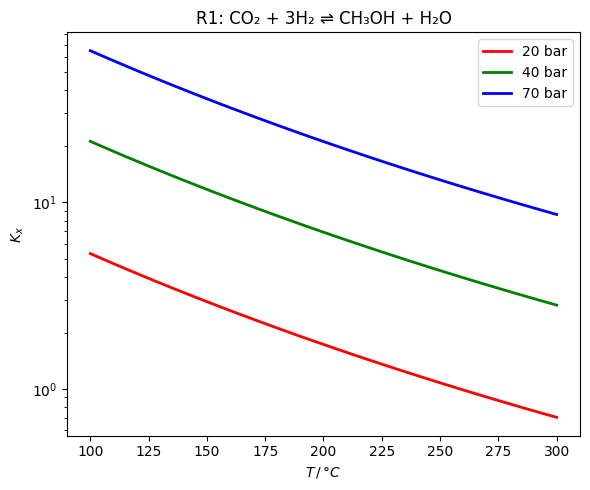

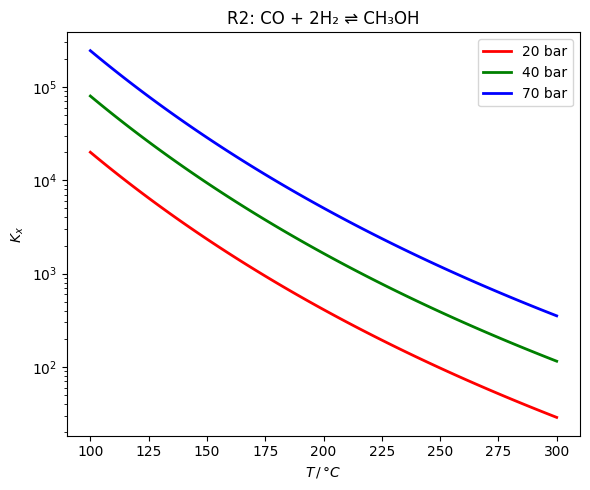

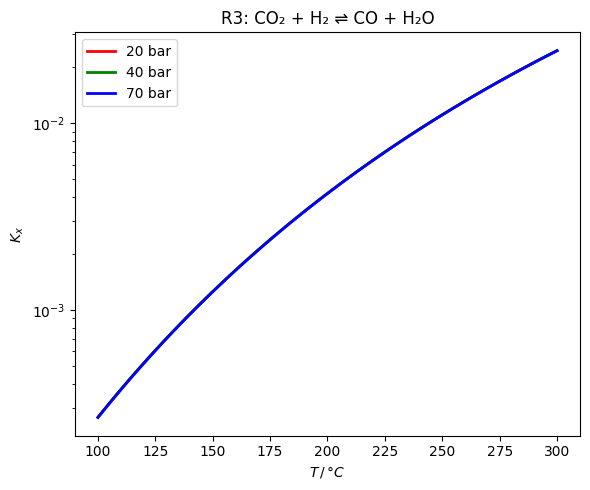

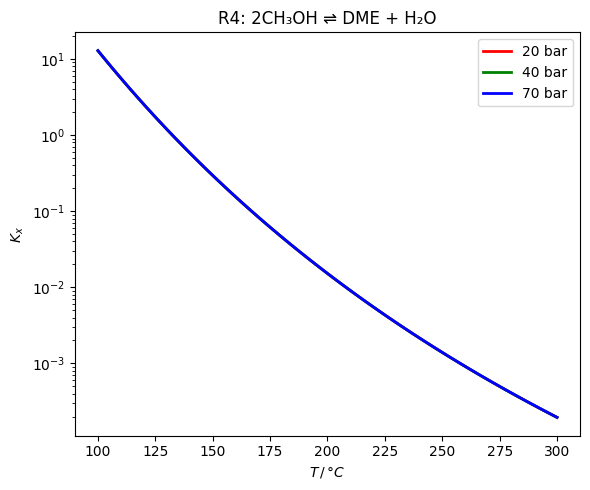

In [5]:
# EQUILIBRIUM CONSTANTS vs T and p

def plot_Kx(T_range, p_range, rxn_func, rxn_name, delta_nu):
    """Plot equilibrium constant K_x vs temperature for different pressures."""
    K_x = np.empty([len(p_range), len(T_range)])
    p_std = 1  # bar
    
    for i, T in enumerate(T_range):
        K_eq = rxn_func(T)[-1]
        K_x[:, i] = K_eq * (p_range / p_std)**(-delta_nu)
    
    plt.figure(figsize=(6, 5))
    plt.grid()
    plt.title(f"{rxn_name}")
    plt.xlabel(r"$T\,/\,°C$")
    plt.ylabel(r"$K_x$")
    plt.yscale('log')
    
    colors = ["r-", "g-", "b-"]
    for i, (p_val, color) in enumerate(zip(p_range, colors)):
        plt.plot(T_range - 273, K_x[i, :], color, label=f"{p_val:.0f} bar", linewidth=2)
    
    plt.grid()
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()


# Calculate and plot K_x for all reactions
T_range = np.linspace(100+273, 300+273, 100)
p_range = np.array([20, 40, 70])

reactions_plot = [
    (rxn_data_1, "R1: CO₂ + 3H₂ ⇌ CH₃OH + H₂O", -2),
    (rxn_data_2, "R2: CO + 2H₂ ⇌ CH₃OH", -2),
    (rxn_data_3, "R3: CO₂ + H₂ ⇌ CO + H₂O", 0),
    (rxn_data_4, "R4: 2CH₃OH ⇌ DME + H₂O", 0)
]

for rxn_func, rxn_name, delta_nu in reactions_plot:
    plot_Kx(T_range, p_range, rxn_func, rxn_name, delta_nu)


## 3.5 Stoichiometry and Reaction Extent for DME System

### 3.5.1 Soichiometry

For a reaction system, the outlet molar flow rate of component $i$ can be related to the inlet molar flow rate and reaction extents as:

\begin{equation}
\dot n_{i,out}
=
\dot n_{i,in}
+
\sum_j \nu_{i,j}\xi_j
\tag{20}
\end{equation}

With:

- $\dot n_{i,in}$ is the inlet molar flow rate of component $i$
- $\dot n_{i,out}$ is the outlet molar flow rate of component $i$
- $\nu_{i,j}$ is the stoichiometric coefficient of component $i$ in reaction $j$
- $\xi_j$ is the reaction extent of reaction $j$

Reactants have negative stoichiometric coefficients, while products have positive stoichiometric coefficients.

### Stoichiometric Matrix

Using the species order:

$$
[CO_2,\ H_2,\ CH_3OH,\ H_2O,\ CO,\ DME]
$$

and the reaction order:

$$
[R_1,\ R_2,\ R_3,\ R_4]
$$

the stoichiometric matrix is:

\begin{equation}
N =
\begin{bmatrix}
-1 & 0 & -1 & 0\\
-3 & -2 & -1 & 0\\
1 & 1 & 0 & -2\\
1 & 0 & 1 & 1\\
0 & -1 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix}
\tag{M2}
\end{equation}

The same matrix can be written with labels as:

\begin{array}{c|cccc}
 & R_1 & R_2 & R_3 & R_4\\
\hline
CO_2 & -1 & 0 & -1 & 0\\
H_2 & -3 & -2 & -1 & 0\\
CH_3OH & 1 & 1 & 0 & -2\\
H_2O & 1 & 0 & 1 & 1\\
CO & 0 & -1 & 1 & 0\\
DME & 0 & 0 & 0 & 1
\end{array}
\end{equation}

The full material balance can be written in matrix form as:

\begin{equation}
\dot{\mathbf n}_{out}
=
\dot{\mathbf n}_{in}
+
N\boldsymbol{\xi}
\tag{21}
\end{equation}

with:

$$
\boldsymbol{\xi}
=
\begin{bmatrix}
\xi_1\\
\xi_2\\
\xi_3\\
\xi_4
\end{bmatrix}
$$

### Individual Component Material Balances

For CO<sub>2</sub>, it is consumed in $R_1$ and $R_3$:

\begin{equation}
\dot n_{CO_2,out}
=
\dot n_{CO_2,in}
-
\xi_1
-
\xi_3
\tag{22}
\end{equation}

For H<sub>2</sub>, it is consumed in $R_1$, $R_2$, and $R_3$:

\begin{equation}
\dot n_{H_2,out}
=
\dot n_{H_2,in}
-
3\xi_1
-
2\xi_2
-
\xi_3
\tag{23}
\end{equation}

For methanol, it is produced in $R_1$ and $R_2$, but consumed in $R_4$:

\begin{equation}
\dot n_{CH_3OH,out}
=
\dot n_{CH_3OH,in}
+
\xi_1
+
\xi_2
-
2\xi_4
\tag{24}
\end{equation}

For water, it is produced in $R_1$, $R_3$, and $R_4$:

\begin{equation}
\dot n_{H_2O,out}
=
\dot n_{H_2O,in}
+
\xi_1
+
\xi_3
+
\xi_4
\tag{25}
\end{equation}

For CO, it is consumed in $R_2$, but produced in $R_3$:

\begin{equation}
\dot n_{CO,out}
=
\dot n_{CO,in}
-
\xi_2
+
\xi_3
\tag{26}
\end{equation}

For DME, it is produced only in $R_4$:

\begin{equation}
\dot n_{DME,out}
=
\dot n_{DME,in}
+
\xi_4
\tag{27}
\end{equation}

### Total Outlet Molar Flow Rate

The total outlet molar flow rate is:

\begin{equation}
\dot n_{tot,out}
=
\sum_i \dot n_{i,out}
\tag{28}
\end{equation}

The change in total moles for each reaction is calculated as follows.

For $R_1$:

\begin{equation}
CO_2 + 3H_2 \rightleftharpoons CH_3OH + H_2O
\tag{R1}
\end{equation}

\begin{equation}
\Delta \nu_1 = (1+1) - (1+3) = -2
\tag{29}
\end{equation}

For $R_2$:

\begin{equation}
CO + 2H_2 \rightleftharpoons CH_3OH
\tag{R2}
\end{equation}

\begin{equation}
\Delta \nu_2 = 1 - (1+2) = -2
\tag{30}
\end{equation}

For $R_3$:

\begin{equation}
CO_2 + H_2 \rightleftharpoons CO + H_2O
\tag{R3}
\end{equation}

\begin{equation}
\Delta \nu_3 = (1+1) - (1+1) = 0
\tag{31}
\end{equation}

For $R_4$:

\begin{equation}
2CH_3OH \rightleftharpoons DME + H_2O
\tag{R4}
\end{equation}

\begin{equation}
\Delta \nu_4 = (1+1) - 2 = 0
\tag{32}
\end{equation}

Therefore, the total outlet molar flow rate is:

\begin{equation}
\dot n_{tot,out}
=
\dot n_{tot,in}
-
2\xi_1
-
2\xi_2
+
0\xi_3
+
0\xi_4
\tag{33}
\end{equation}

or simply:

\begin{equation}
\boxed{
\dot n_{tot,out}
=
\dot n_{tot,in}
-
2\xi_1
-
2\xi_2
}
\tag{34}
\end{equation}

### Mole Fractions at the Outlet

The outlet mole fraction of each component is:

\begin{equation}
x_{i,out}
=
\frac{\dot n_{i,out}}
{\dot n_{tot,out}}
\tag{35}
\end{equation}

Therefore, the outlet mole fractions are:

\begin{equation}
x_{CO_2,out}
=
\frac{
\dot n_{CO_2,in}
-
\xi_1
-
\xi_3
}
{
\dot n_{tot,in}
-
2\xi_1
-
2\xi_2
}
\tag{36}
\end{equation}

\begin{equation}
x_{H_2,out}
=
\frac{
\dot n_{H_2,in}
-
3\xi_1
-
2\xi_2
-
\xi_3
}
{
\dot n_{tot,in}
-
2\xi_1
-
2\xi_2
}
\tag{37}
\end{equation}

\begin{equation}
x_{CH_3OH,out}
=
\frac{
\dot n_{CH_3OH,in}
+
\xi_1
+
\xi_2
-
2\xi_4
}
{
\dot n_{tot,in}
-
2\xi_1
-
2\xi_2
}
\tag{38}
\end{equation}

\begin{equation}
x_{H_2O,out}
=
\frac{
\dot n_{H_2O,in}
+
\xi_1
+
\xi_3
+
\xi_4
}
{
\dot n_{tot,in}
-
2\xi_1
-
2\xi_2
}
\tag{39}
\end{equation}

\begin{equation}
x_{CO,out}
=
\frac{
\dot n_{CO,in}
-
\xi_2
+
\xi_3
}
{
\dot n_{tot,in}
-
2\xi_1
-
2\xi_2
}
\tag{40}
\end{equation}

\begin{equation}
x_{DME,out}
=
\frac{
\dot n_{DME,in}
+
\xi_4
}
{
\dot n_{tot,in}
-
2\xi_1
-
2\xi_2
}
\tag{41}
\end{equation}

## 3.5.2 Calculation of Reaction Extent and Equilibrium Composition

For the calculation of reaction extents, the roots of the equilibrium functions are solved numerically. The outlet mole fractions $x_{i,out}$ depend on the reaction extents $\xi_j$, while the equilibrium constants $K_j^\circ(T)$ are calculated from thermodynamic data.

The general equilibrium condition is:

\begin{equation}
Q_j = K_j^\circ(T)
\tag{42}
\end{equation}

or in residual form:

\begin{equation}
0 = Q_j - K_j^\circ(T)
\tag{43}
\end{equation}

For ideal gases:

\begin{equation}
a_i = x_i \frac{p}{p^\circ}
\tag{44}
\end{equation}

### Reaction 1: CO<sub>2</sub> Hydrogenation to Methanol

\begin{equation}
CO_2 + 3H_2 \rightleftharpoons CH_3OH + H_2O
\tag{R1}
\end{equation}

The activity-based equilibrium equation is:

\begin{equation}
K_1^\circ(T)
=
\frac{a_{CH_3OH}a_{H_2O}}
{a_{CO_2}a_{H_2}^{3}}
\tag{45}
\end{equation}

Using ideal gas activities:

\begin{equation}
K_1^\circ(T)
=
\frac{x_{CH_3OH}x_{H_2O}}
{x_{CO_2}x_{H_2}^{3}}
\left(\frac{p}{p^\circ}\right)^{-2}
\tag{46}
\end{equation}

Rearranging into root function form:

\begin{equation}
\boxed{
0
=
K_1^\circ(T)
\left(\frac{p}{p^\circ}\right)^2
x_{CO_2}x_{H_2}^{3}
-
x_{CH_3OH}x_{H_2O}
}
\tag{47}
\end{equation}

### Reaction 2: CO Hydrogenation to Methanol

\begin{equation}
CO + 2H_2 \rightleftharpoons CH_3OH
\tag{R2}
\end{equation}

The activity-based equilibrium equation is:

\begin{equation}
K_2^\circ(T)
=
\frac{a_{CH_3OH}}
{a_{CO}a_{H_2}^{2}}
\tag{48}
\end{equation}

Using ideal gas activities:

\begin{equation}
K_2^\circ(T)
=
\frac{x_{CH_3OH}}
{x_{CO}x_{H_2}^{2}}
\left(\frac{p}{p^\circ}\right)^{-2}
\tag{49}
\end{equation}

Rearranging into root function form:

\begin{equation}
\boxed{
0
=
K_2^\circ(T)
\left(\frac{p}{p^\circ}\right)^2
x_{CO}x_{H_2}^{2}
-
x_{CH_3OH}
}
\tag{50}
\end{equation}

### Reaction 3: Reverse Water Gas Shift Reaction

\begin{equation}
CO_2 + H_2 \rightleftharpoons CO + H_2O
\tag{R3}
\end{equation}

The activity-based equilibrium equation is:

\begin{equation}
K_3^\circ(T)
=
\frac{a_{CO}a_{H_2O}}
{a_{CO_2}a_{H_2}}
\tag{51}
\end{equation}

For this reaction, the number of gas moles is the same on both sides:

\begin{equation}
\Delta \nu_3 = 0
\tag{52}
\end{equation}

Therefore, the pressure term cancels:

\begin{equation}
K_3^\circ(T)
=
\frac{x_{CO}x_{H_2O}}
{x_{CO_2}x_{H_2}}
\tag{53}
\end{equation}

Rearranging into root function form:

\begin{equation}
\boxed{
0
=
K_3^\circ(T)x_{CO_2}x_{H_2}
-
x_{CO}x_{H_2O}
}
\tag{54}
\end{equation}

### Reaction 4: Methanol Dehydration to DME

\begin{equation}
2CH_3OH \rightleftharpoons CH_3OCH_3 + H_2O
\tag{R4}
\end{equation}

The activity-based equilibrium equation is:

\begin{equation}
K_4^\circ(T)
=
\frac{a_{DME}a_{H_2O}}
{a_{CH_3OH}^{2}}
\tag{55}
\end{equation}

Using ideal gas activities:

\begin{equation}
K_4^\circ(T)
=
\frac{x_{DME}x_{H_2O}}
{x_{CH_3OH}^{2}}
\tag{56}
\end{equation}

For this reaction:

\begin{equation}
\Delta \nu_4 = 0
\tag{57}
\end{equation}

Therefore, the pressure term cancels.

Rearranging into root function form:

\begin{equation}
\boxed{
0
=
K_4^\circ(T)x_{CH_3OH}^{2}
-
x_{DME}x_{H_2O}
}
\tag{58}
\end{equation}

### Final Root Equations for the DME System

The final system of nonlinear equilibrium equations can be written as:

\begin{equation}
\boxed{
f_1
=
K_1^\circ(T)
\left(\frac{p}{p^\circ}\right)^2
x_{CO_2}x_{H_2}^{3}
-
x_{CH_3OH}x_{H_2O}
=
0
}
\tag{59}
\end{equation}

\begin{equation}
\boxed{
f_2
=
K_2^\circ(T)
\left(\frac{p}{p^\circ}\right)^2
x_{CO}x_{H_2}^{2}
-
x_{CH_3OH}
=
0
}
\tag{60}
\end{equation}

\begin{equation}
\boxed{
f_3
=
K_3^\circ(T)
x_{CO_2}x_{H_2}
-
x_{CO}x_{H_2O}
=
0
}
\tag{61}
\end{equation}

\begin{equation}
\boxed{
f_4
=
K_4^\circ(T)
x_{CH_3OH}^{2}
-
x_{DME}x_{H_2O}
=
0
}
\tag{62}
\end{equation}

These equations are solved numerically in Python to calculate the reaction extents and the final equilibrium outlet composition of the DME system.

## 4. Equilibrium Composition Solver

This section solves the nonlinear equilibrium equations to calculate the reaction extents and outlet composition.

The unknowns in the solver are:

$$
\xi_1,\ \xi_2,\ \xi_4
$$

These correspond to the selected independent reactions $R_1$, $R_2$ and $R_4$. The outlet molar flows are first calculated from the material balance. Then, the outlet mole fractions are used in the law-of-mass-action equations.

The equilibrium equations are solved numerically using the `root` function. The `lm` method is used because it provided stable results for this coupled reaction network. The solution from the previous temperature step is used as the initial guess for the next step, which improves convergence.

The inlet feed used in this calculation is:

$$
\dot{n}_{CO_2,in} = 2.0\ \mathrm{mol\,s^{-1}}
$$

$$
\dot{n}_{H_2,in} = 6.0\ \mathrm{mol\,s^{-1}}
$$

This corresponds to a stoichiometric H<sub>2</sub>/CO<sub>2</sub> ratio of 3 for CO<sub>2</sub> hydrogenation.

In [6]:
# EQUILIBRIUM COMPOSITION SOLVER

def composition(xi, n_in):
    """Calculate outlet molar fractions from reaction extents."""
    xi1, xi2, xi4 = xi
    n_out = np.sum(n_in) - 2*xi1 - 2*xi2
    
    if n_out <= 1e-10:
        return np.full(6, np.nan)
    
    x = np.array([
        (n_in[0] - xi1) / n_out,              # CO2
        (n_in[1] - 3*xi1 - 2*xi2) / n_out,    # H2
        (n_in[2] + xi1 + xi2 - 2*xi4) / n_out,# CH3OH
        (n_in[3] + xi1 + xi4) / n_out,        # H2O
        (n_in[4] - xi2) / n_out,              # CO
        (n_in[5] + xi4) / n_out               # DME
    ])
    
    return x


def rxn_ext(xi, n_in, T, p):
    """System of equilibrium equations."""
    x = composition(xi, n_in)
    
    if np.any(np.isnan(x)) or np.any(x <= 0):
        return np.array([1e6, 1e6, 1e6])
    
    x_CO2, x_H2, x_CH3OH, x_H2O, x_CO, x_DME = x
    
    # Get equilibrium constants
    K1 = rxn_data_1(T)[-1]
    K2 = rxn_data_2(T)[-1]
    K4 = rxn_data_4(T)[-1]
    
    # Convert to K_x
    p_std = 1
    Kx1 = K1 * (p/p_std)**2
    Kx2 = K2 * (p/p_std)**2
    Kx4 = K4
    
    # Equilibrium equations
    res1 = Kx1 * x_CO2 * x_H2**3 - x_CH3OH * x_H2O
    res2 = Kx2 * x_CO * x_H2**2 - x_CH3OH
    res4 = Kx4 * x_CH3OH**2 - x_DME * x_H2O
    
    return [res1, res2, res4]


# Setup and solve
n_in = np.array([2.0, 6.0, 0.0, 0.0, 0.0, 0.0])  # CO2, H2, CH3OH, H2O, CO, DME
T_calc = np.linspace(100+273, 300+273, 40)
p_calc = np.array([20, 50, 70])

xi = np.empty([len(p_calc), len(T_calc), 3])

# Solve for each pressure and temperature
for ip, p_val in enumerate(p_calc):
    print(f"\nPressure: {p_val} bar")
    
    for iT in range(len(T_calc)):  # Low to high T
        T_val = T_calc[iT]
        
        xi_guess = np.array([0.3, -0.05, 0.05]) if iT == 0 else xi[ip, iT-1, :]
        
        try:
            result = root(rxn_ext, xi_guess, args=(n_in, T_val, p_val), method='lm')
            
            if result.success:
                xi[ip, iT, :] = result.x
                if iT % 8 == 0:
                    print(f"  T={T_val-273:.0f}°C: ξ=[{result.x[0]:.4f}, {result.x[1]:.5f}, {result.x[2]:.4f}]")
            else:
                result = root(rxn_ext, xi_guess, args=(n_in, T_val, p_val), method='hybr')
                xi[ip, iT, :] = result.x if result.success else np.nan * np.ones(3)
        except Exception as e:
            print(f"  ERROR at T={T_val-273:.0f}°C: {e}")
            xi[ip, iT, :] = np.nan * np.ones(3)



Pressure: 20 bar
  T=100°C: ξ=[1.4259, -0.00013, 0.5650]
  T=141°C: ξ=[1.2107, -0.00127, 0.2219]
  T=182°C: ξ=[1.0915, -0.00619, 0.0369]
  T=223°C: ξ=[1.0162, -0.01943, 0.0045]
  T=264°C: ξ=[0.9580, -0.04927, 0.0007]

Pressure: 50 bar
  T=100°C: ξ=[1.6275, -0.00005, 0.6449]
  T=141°C: ξ=[1.4755, -0.00046, 0.2707]
  T=182°C: ξ=[1.3850, -0.00223, 0.0472]
  T=223°C: ξ=[1.3234, -0.00701, 0.0061]
  T=264°C: ξ=[1.2697, -0.01799, 0.0009]

Pressure: 70 bar
  T=100°C: ξ=[1.6836, -0.00003, 0.6671]
  T=141°C: ξ=[1.5523, -0.00032, 0.2848]
  T=182°C: ξ=[1.4729, -0.00154, 0.0503]
  T=223°C: ξ=[1.4179, -0.00484, 0.0065]
  T=264°C: ξ=[1.3691, -0.01241, 0.0010]


## 5. Reaction Extents

The reaction extent plots show the effect of temperature and pressure on the independent reactions.

For $R_1$, the extent decreases with increasing temperature because methanol synthesis from CO<sub>2</sub> is exothermic. Higher pressure increases the extent of $R_1$, which is expected because the reaction reduces the number of gas-phase moles.

For $R_2$, the calculated reaction extent is slightly negative. This means that, in the chosen independent reaction basis, the reverse direction of $R_2$ contributes slightly to the equilibrium composition. This is physically possible because the inlet contains CO<sub>2</sub> and H<sub>2</sub>, while CO is not initially fed and is only generated through the coupled equilibrium network.

For $R_4$, the extent is highest at lower temperature. This indicates that methanol dehydration to DME is thermodynamically more favourable at lower temperature. Pressure does not directly appear in the $R_4$ equilibrium expression because $\Delta\nu_4 = 0$, but pressure affects $R_4$ indirectly by changing the amount of methanol available from the upstream reactions.

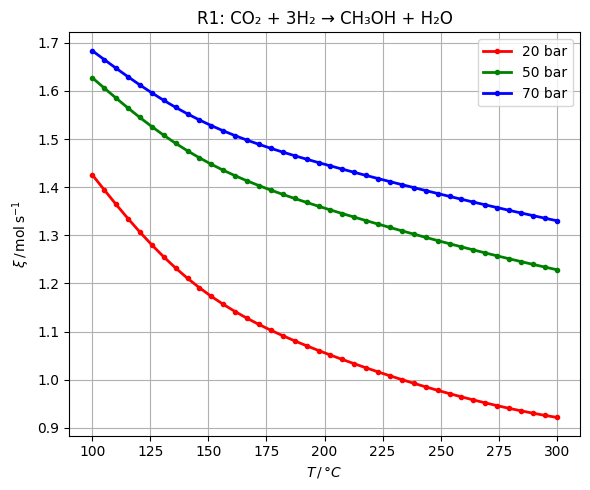

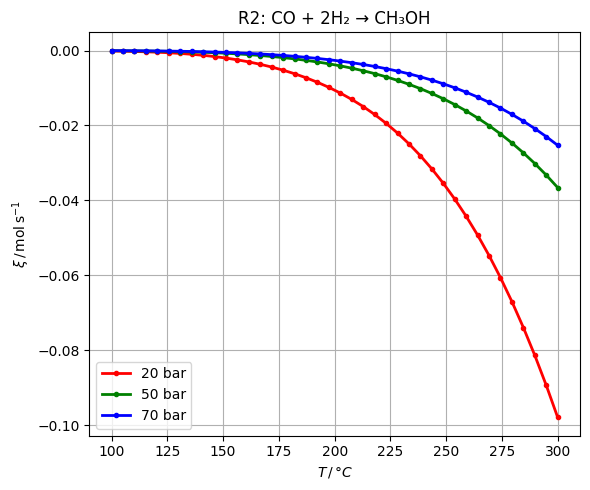

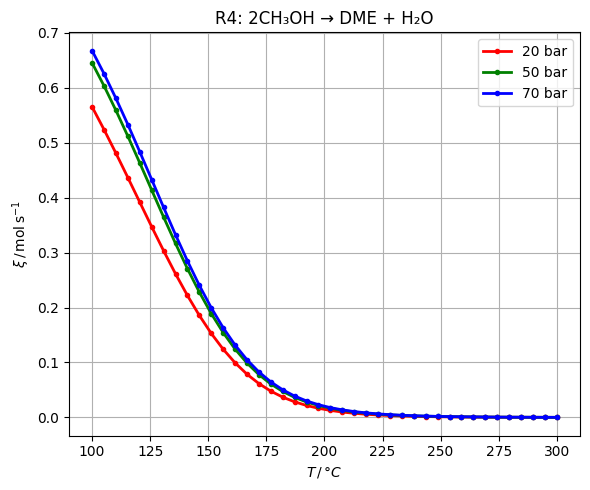

In [7]:
# RESULTS: REACTION EXTENTS (with method "lm")

reaction_labels = ["R1: CO₂ + 3H₂ → CH₃OH + H₂O", 
                   "R2: CO + 2H₂ → CH₃OH",
                   "R4: 2CH₃OH → DME + H₂O"]
colors = ["r-", "g-", "b-"]

for rxn_idx in range(3):
    plt.figure(figsize=(6, 5))
    plt.grid()
    plt.title(reaction_labels[rxn_idx])
    plt.xlabel(r"$T\,/\,°C$")
    plt.ylabel(r"$\xi\,/\,\mathrm{mol\,s^{-1}}$")
    
    for ip, p_val in enumerate(p_calc):
        plt.plot(T_calc - 273, xi[ip, :, rxn_idx], colors[ip], 
                label=f"{p_val:.0f} bar", linewidth=2, marker='o', markersize=3)
    
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()


## 6. Outlet Composition

The outlet molar flow rates are calculated from the solved reaction extents. These plots show how each species changes with temperature and pressure.

At lower temperature, more DME is formed because the exothermic synthesis route is more thermodynamically favourable. As temperature increases, the DME outlet flow decreases and the system shifts towards more methanol, water and unconverted reactants.

The outlet composition at 50 bar is used as a reference case to compare all components on the same plot. CO<sub>2</sub> and H<sub>2</sub> are consumed, while methanol and water are formed. CO remains low because it is not present in the inlet and only appears due to the coupled reaction network. DME is present mainly at lower temperatures.

Mole fractions are important because the equilibrium equations are based on ideal gas activities:

\begin{equation}
a_i = x_i\frac{p}{p^\circ}
\tag{63}
\end{equation}

The outlet mole fraction plot shows the relative amount of each component in the product gas mixture. This helps interpret the equilibrium composition more clearly than molar flow rates alone.

The DME mole fraction is higher at lower temperature and decreases as temperature increases. This trend is consistent with the exothermic nature of the overall DME formation pathway.

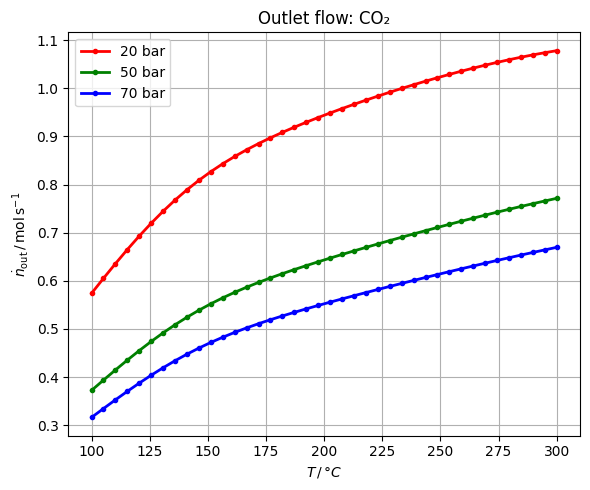

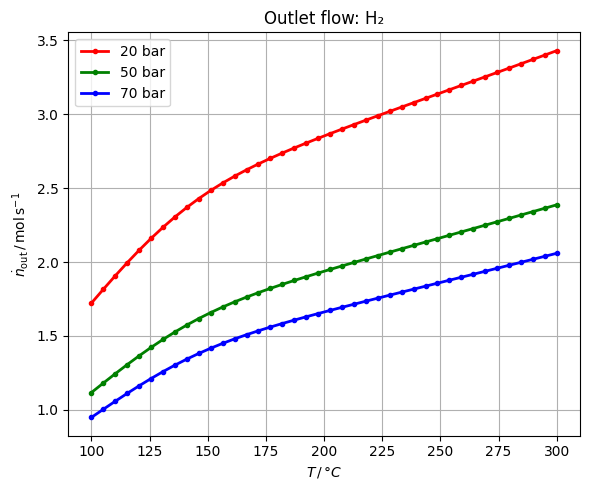

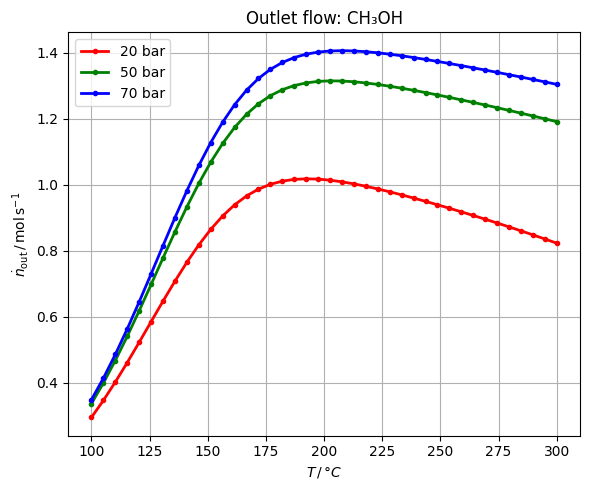

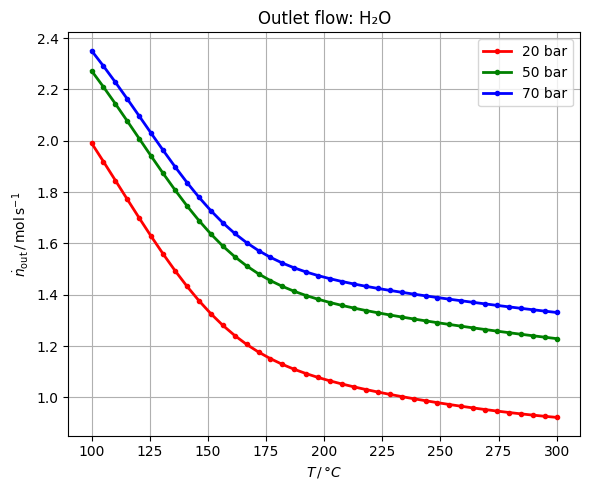

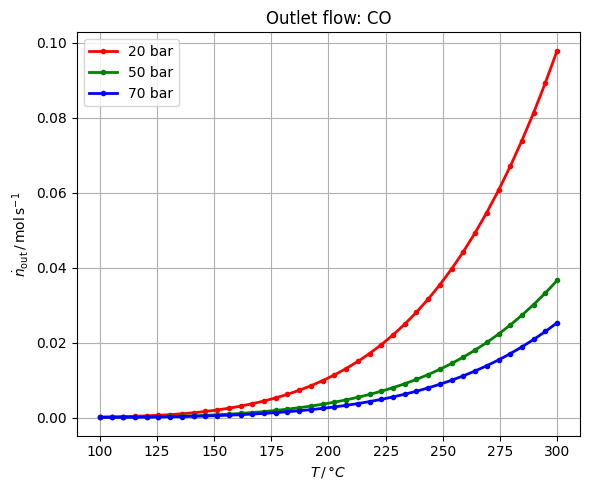

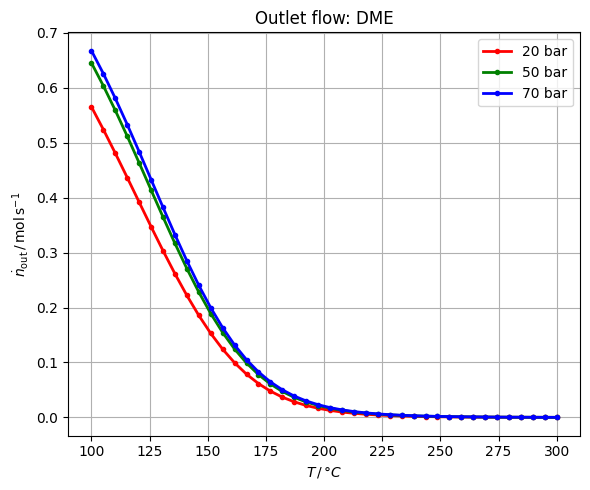

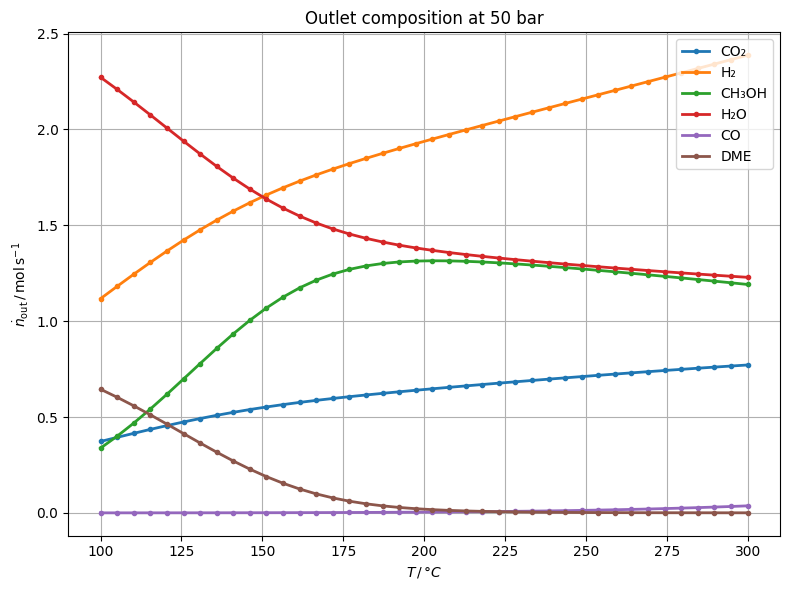

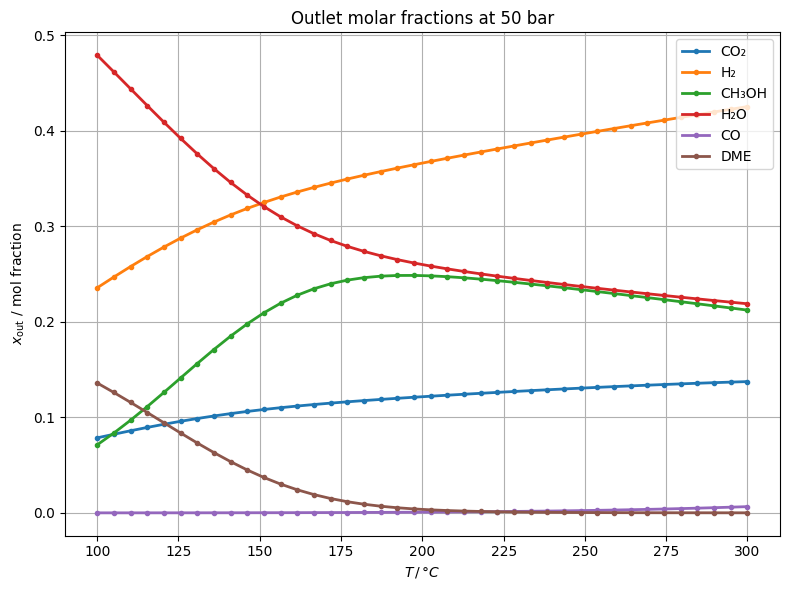

In [8]:
# RESULTS: OUTLET COMPOSITION

# Calculate outlet flows
n_out_all = np.empty([len(p_calc), len(T_calc), 6])

for ip in range(len(p_calc)):
    for iT in range(len(T_calc)):
        if not np.isnan(xi[ip, iT, 0]):
            xi1, xi2, xi4 = xi[ip, iT, :]
            n_out_all[ip, iT, :] = [
                n_in[0] - xi1,                     # CO2
                n_in[1] - 3*xi1 - 2*xi2,           # H2
                n_in[2] + xi1 + xi2 - 2*xi4,       # CH3OH
                n_in[3] + xi1 + xi4,               # H2O
                n_in[4] - xi2,                     # CO
                n_in[5] + xi4                      # DME
            ]
        else:
            n_out_all[ip, iT, :] = np.nan * np.ones(6)

# Plot individual component flows
comp_names = ["CO₂", "H₂", "CH₃OH", "H₂O", "CO", "DME"]

for ic, comp_name in enumerate(comp_names):
    plt.figure(figsize=(6, 5))
    plt.grid()
    plt.title(f"Outlet flow: {comp_name}")
    plt.xlabel(r"$T\,/\,°C$")
    plt.ylabel(r"$\dot{n}_{\mathrm{out}}\,/\,\mathrm{mol\,s^{-1}}$")
    
    for ip, p_val in enumerate(p_calc):
        plt.plot(T_calc - 273, n_out_all[ip, :, ic], colors[ip],
                label=f"{p_val:.0f} bar", linewidth=2, marker='o', markersize=3)
    
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

# Plot all components at reference pressure
ip_ref = 1  # 50 bar
plt.figure(figsize=(8, 6))
plt.grid()
plt.title(f"Outlet composition at {p_calc[ip_ref]:.0f} bar")
plt.xlabel(r"$T\,/\,°C$")
plt.ylabel(r"$\dot{n}_{\mathrm{out}}\,/\,\mathrm{mol\,s^{-1}}$")

for ic, comp_name in enumerate(comp_names):
    plt.plot(T_calc - 273, n_out_all[ip_ref, :, ic],
            label=comp_name, linewidth=2, marker='o', markersize=3)

plt.legend(loc='best')
plt.tight_layout()
plt.show()

# Calculate and plot molar fractions
x_out_all = np.empty([len(p_calc), len(T_calc), 6])

for ip in range(len(p_calc)):
    for iT in range(len(T_calc)):
        if not np.isnan(n_out_all[ip, iT, 0]):
            n_total = np.sum(n_out_all[ip, iT, :])
            x_out_all[ip, iT, :] = n_out_all[ip, iT, :] / n_total
        else:
            x_out_all[ip, iT, :] = np.nan * np.ones(6)

plt.figure(figsize=(8, 6))
plt.grid()
plt.title(f"Outlet molar fractions at {p_calc[ip_ref]:.0f} bar")
plt.xlabel(r"$T\,/\,°C$")
plt.ylabel(r"$x_{\mathrm{out}}$ / mol fraction")

for ic, comp_name in enumerate(comp_names):
    plt.plot(T_calc - 273, x_out_all[ip_ref, :, ic],
            label=comp_name, linewidth=2, marker='o', markersize=3)

plt.legend(loc='best')
plt.tight_layout()
plt.show()


## 7. Three-Dimensional Surface Plots

The 3D surface plots show the combined effect of temperature and pressure on the reaction extents. Instead of studying temperature or pressure separately, these plots show how both variables influence the equilibrium solution at the same time.

For each temperature-pressure combination, the equilibrium solver calculates the reaction extents. The resulting surfaces help identify the operating region where each reaction is thermodynamically favoured.

These plots are useful for process design because industrial reactor performance depends on both temperature and pressure. They also provide a clearer visual comparison of how $R_1$, $R_2$ and $R_4$ respond to operating conditions.

For both the temperature and the pressure 40 points are calculated for each of the three key reactions.
Therefore 4800 data points have to be calculated, which takes some time.

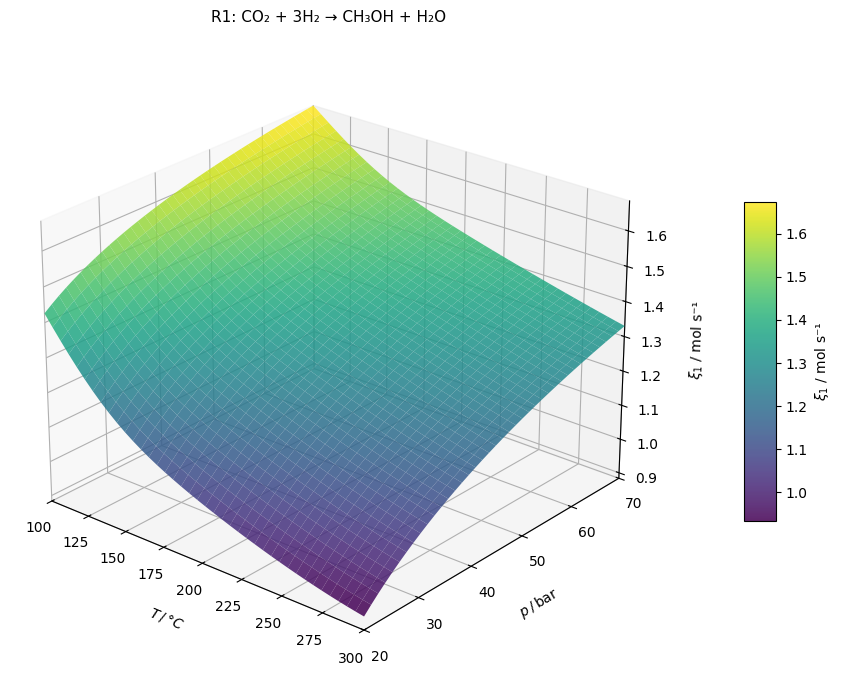

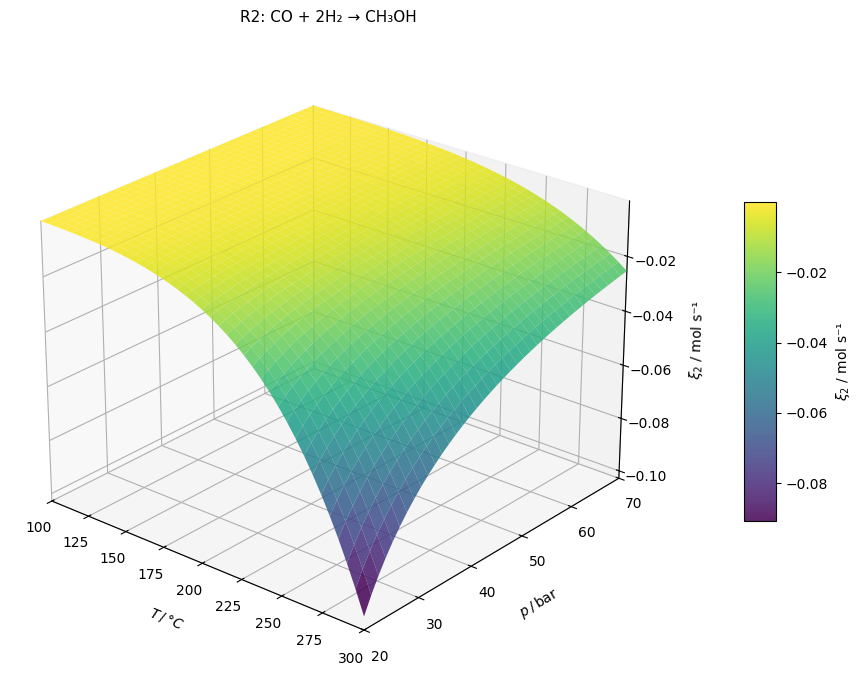

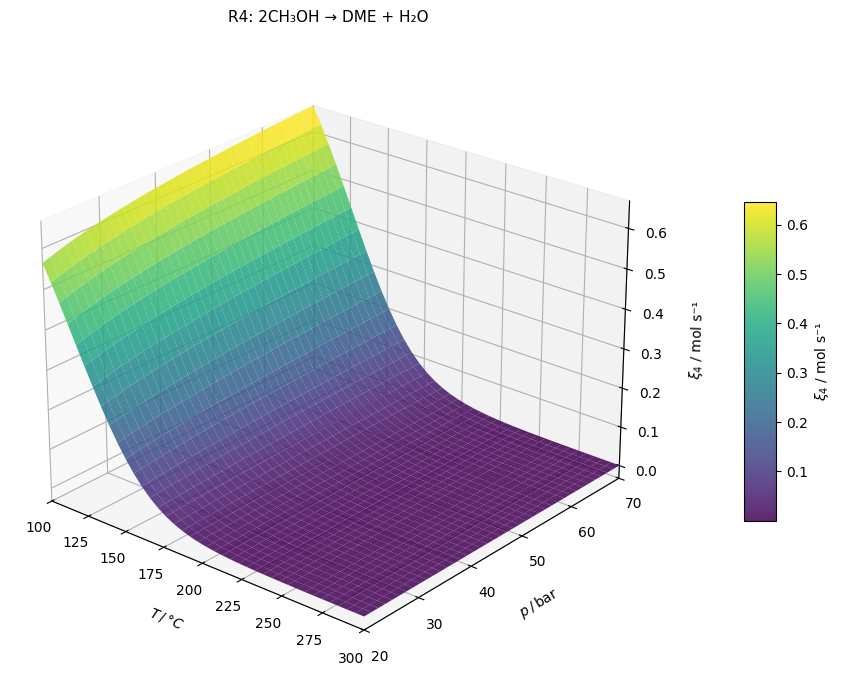

In [9]:
# 3D SURFACE PLOTS 

# Create meshgrid for T and p
T_calc_grid = np.linspace(100+273, 300+273, 40)
p_calc_grid = np.linspace(20, 70, 40)

xi_3D = np.empty([len(p_calc_grid), len(T_calc_grid), 3])

for ip, p_val in enumerate(p_calc_grid):
    
    for iT in range(len(T_calc_grid)):  # Low to high T
        T_val = T_calc_grid[iT]
        
        xi_guess = np.array([0.3, -0.05, 0.05]) if iT == 0 else xi_3D[ip, iT-1, :]
        
        try:
            result = root(rxn_ext, xi_guess, args=(n_in, T_val, p_val), method='lm')
            
            if result.success:
                xi_3D[ip, iT, :] = result.x
            else:
                result = root(rxn_ext, xi_guess, args=(n_in, T_val, p_val), method='hybr')
                xi_3D[ip, iT, :] = result.x if result.success else np.nan * np.ones(3)
        except Exception as e:
            print(f"  ERROR at T={T_val-273:.0f}°C: {e}")
            xi_3D[ip, iT, :] = np.nan * np.ones(3)



T_grid, p_grid = np.meshgrid(T_calc_grid - 273, p_calc_grid)

reaction_labels_3d = [
    "R1: CO₂ + 3H₂ → CH₃OH + H₂O",
    "R2: CO + 2H₂ → CH₃OH",
    "R4: 2CH₃OH → DME + H₂O"
]
xi_labels = [r"$\xi_1$", r"$\xi_2$", r"$\xi_4$"]

for rxn_idx in range(3):
    Z = xi_3D[:, :, rxn_idx]   # shape: (40, 40) — now matches grid

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    # 3D surface
    surf = ax.plot_surface(
        T_grid, p_grid, Z,
        cmap='viridis',
        alpha=0.85,
        linewidth=0,
        antialiased=True
    )

    z_floor = np.nanmin(Z) - 0.05 * (np.nanmax(Z) - np.nanmin(Z))

    # Colorbar, labels, title
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.1,
                 label=f"{xi_labels[rxn_idx]} / mol s⁻¹")
    ax.set_xlabel(r"$T\,/\,°C$", labelpad=10)
    ax.set_ylabel(r"$p\,/\,\mathrm{bar}$", labelpad=10)
    ax.set_zlabel(f"{xi_labels[rxn_idx]} / mol s⁻¹", labelpad=10)
    ax.set_title(reaction_labels_3d[rxn_idx], fontsize=11, pad=15)
    ax.set_xlim(T_calc[0] - 273, T_calc[-1] - 273)
    ax.set_ylim(p_calc[0], p_calc[-1])
    ax.set_zlim(z_floor, np.nanmax(Z))
    ax.view_init(elev=25, azim=-50)

    plt.tight_layout()
    plt.show()

## 8. Summary Table at Selected Temperature

The summary table reports the inlet flow, outlet flow, flow change and outlet mole fraction at approximately $249^\circ C$. This temperature is close to typical conditions used in direct DME synthesis studies as described in the introduction.

The table compares the effect of pressure. As pressure increases, CO<sub>2</sub> conversion increases because the methanol synthesis reactions are favoured by pressure. The total outlet molar flow decreases because the main hydrogenation reactions reduce the number of gas-phase moles.

The DME flow remains small under the selected conditions, which suggests that methanol formation is more dominant than DME formation in this equilibrium calculation. This highlights the importance of catalyst selection and methanol dehydration activity in practical direct DME synthesis.

In [10]:
# SUMMARY TABLE

T_idx = np.argmin(np.abs(T_calc - (250+273)))

print("\n" + "=" * 60)
print(f"OUTLET FLOWS SUMMARY AT T={T_calc[T_idx]-273:.0f}°C")
print("=" * 60)

for ip, p_val in enumerate(p_calc):
    print(f"\n{'─' * 60}")
    print(f"Pressure: {p_val:.0f} bar")
    print(f"{'─' * 60}")
    print(f"{'Component':<10} {'Inlet':>12} {'Outlet':>12} {'Change':>12} {'x_out':>10}")
    print("─" * 60)
    
    for ic, comp_name in enumerate(comp_names):
        n_out = n_out_all[ip, T_idx, ic]
        x_out = x_out_all[ip, T_idx, ic]
        delta_n = n_out - n_in[ic]
        print(f"{comp_name:<10} {n_in[ic]:>12.4f} {n_out:>12.4f} {delta_n:>12.4f} {x_out*100:>9.2f}%")
    
    print("─" * 60)
    print(f"{'Total':<10} {np.sum(n_in):>12.4f} {np.sum(n_out_all[ip, T_idx, :]):>12.4f}")
    
    # Performance metrics
    xi_vals = xi[ip, T_idx, :]
    conv_CO2 = (n_in[0] - n_out_all[ip, T_idx, 0]) / n_in[0] * 100
    sel_DME = n_out_all[ip, T_idx, 5] / (n_out_all[ip, T_idx, 2] + 2*n_out_all[ip, T_idx, 5]) * 100
    
    print(f"\nReaction extents: ξ₁={xi_vals[0]:.4f}, ξ₂={xi_vals[1]:.5f}, ξ₄={xi_vals[2]:.4f}")
    print(f"CO₂ conversion:   {conv_CO2:.2f}%")
    print(f"DME selectivity:  {sel_DME:.2f}% (C-basis)")

print("\n" + "=" * 60)




OUTLET FLOWS SUMMARY AT T=249°C

────────────────────────────────────────────────────────────
Pressure: 20 bar
────────────────────────────────────────────────────────────
Component         Inlet       Outlet       Change      x_out
────────────────────────────────────────────────────────────
CO₂              2.0000       1.0220      -0.9780     16.71%
H₂               6.0000       3.1369      -2.8631     51.30%
CH₃OH            0.0000       0.9399       0.9399     15.37%
H₂O              0.0000       0.9793       0.9793     16.02%
CO               0.0000       0.0354       0.0354      0.58%
DME              0.0000       0.0013       0.0013      0.02%
────────────────────────────────────────────────────────────
Total            8.0000       6.1149

Reaction extents: ξ₁=0.9780, ξ₂=-0.03544, ξ₄=0.0013
CO₂ conversion:   48.90%
DME selectivity:  0.14% (C-basis)

────────────────────────────────────────────────────────────
Pressure: 50 bar
──────────────────────────────────────────────────

## 9. Solver Comparison

The equilibrium equations are nonlinear, so the numerical result can depend on solver type, initial guess and calculation direction. To check the reliability of the solution, the solvers `lm`, `hybr`, `broyden1` and `anderson` are compared .

The calculation is also tested in two directions: from low temperature to high temperature and from high temperature to low temperature. This matters because the previous solution is used as the initial guess for the next point.

The comparison shows which solver gives the fewest failed calculations and NaN values. This is an important verification step because it confirms that the numerical method was checked rather than accepted without validation.

lm_low_to_high                     :   0/360 NaN values,   0 failures
lm_high_to_low                     :   0/360 NaN values,   0 failures
hybr_low_to_high                   :   0/360 NaN values,   0 failures
hybr_high_to_low                   : 168/360 NaN values,  56 failures


c:\Users\Benjamin\Python\CRE_3\venv\Lib\site-packages\scipy\optimize\_nonlin.py:964: RuntimeWarning: invalid value encountered in divide
  d = v / vdot(df, v)
c:\Users\Benjamin\Python\CRE_3\venv\Lib\site-packages\scipy\optimize\_nonlin.py:964: RuntimeWarning: divide by zero encountered in divide
  d = v / vdot(df, v)
c:\Users\Benjamin\Python\CRE_3\venv\Lib\site-packages\scipy\optimize\_nonlin.py:689: RuntimeWarning: invalid value encountered in dot
  return np.dot(self.collapsed, v)
c:\Users\Benjamin\Python\CRE_3\venv\Lib\site-packages\scipy\optimize\_nonlin.py:712: RuntimeWarning: invalid value encountered in multiply
  self.collapsed += c[:,None] * d[None,:].conj()


broyden1_low_to_high               : 114/360 NaN values,  38 failures
broyden1_high_to_low               :  42/360 NaN values,  14 failures


c:\Users\Benjamin\Python\CRE_3\venv\Lib\site-packages\scipy\optimize\_nonlin.py:1125: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.353237816645605e-23.
  gamma = solve(self.a, df_f)
c:\Users\Benjamin\Python\CRE_3\venv\Lib\site-packages\scipy\optimize\_nonlin.py:1125: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.7557934562465554e-23.
  gamma = solve(self.a, df_f)
c:\Users\Benjamin\Python\CRE_3\venv\Lib\site-packages\scipy\optimize\_nonlin.py:1125: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.688446757435037e-23.
  gamma = solve(self.a, df_f)
c:\Users\Benjamin\Python\CRE_3\venv\Lib\site-packages\scipy\optimize\_nonlin.py:1125: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 6.680305446710865e-23.
  gamma = solve(self.a, df_f)
c:\Users\Benjamin\Python\CRE_3\venv\Lib\site-packages\scipy\optimize\_nonlin.py:1125: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 7.

anderson_low_to_high               :  54/360 NaN values,  18 failures


c:\Users\Benjamin\Python\CRE_3\venv\Lib\site-packages\scipy\optimize\_nonlin.py:1125: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.0433588286580714e-30.
  gamma = solve(self.a, df_f)
c:\Users\Benjamin\Python\CRE_3\venv\Lib\site-packages\scipy\optimize\_nonlin.py:1125: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.9963924894122093e-32.
  gamma = solve(self.a, df_f)
c:\Users\Benjamin\Python\CRE_3\venv\Lib\site-packages\scipy\optimize\_nonlin.py:1125: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.2381603143896838e-32.
  gamma = solve(self.a, df_f)
c:\Users\Benjamin\Python\CRE_3\venv\Lib\site-packages\scipy\optimize\_nonlin.py:1125: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.1870658357611184e-32.
  gamma = solve(self.a, df_f)
c:\Users\Benjamin\Python\CRE_3\venv\Lib\site-packages\scipy\optimize\_nonlin.py:1125: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond =

anderson_high_to_low               :  24/360 NaN values,   8 failures


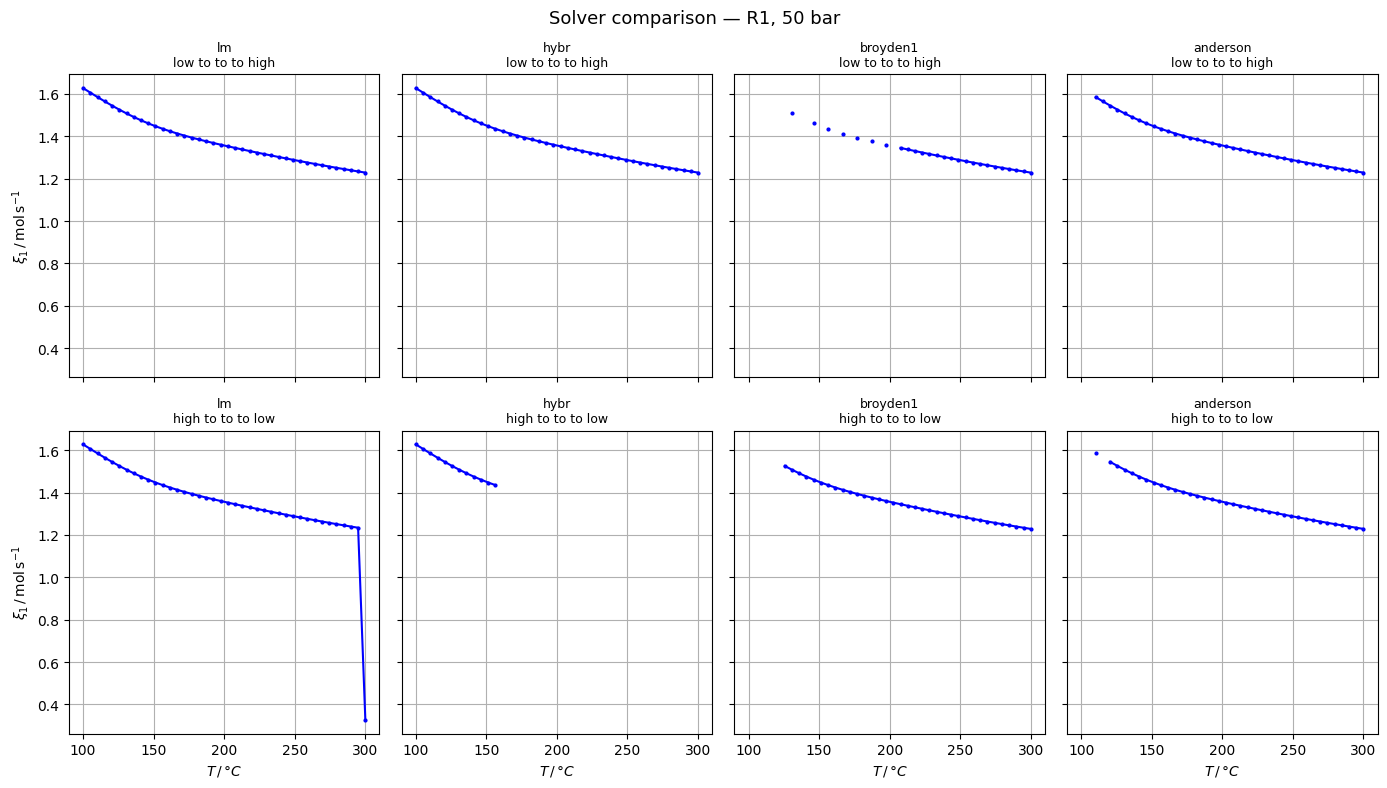


Best combination: lm_low_to_high (0 NaN values)


In [11]:
# Solver Comparison: 'lm', 'hybr', 'broyden1', 'anderson'

methods = ['lm', 'hybr', 'broyden1', 'anderson']
directions = {
    'low_to_high': range(len(T_calc)),
    'high_to_low': range(len(T_calc)-1, -1, -1)
}

# Storage: [method, direction, pressure, temperature, reaction]
xi_test = {}

for method in methods:
    for dir_name, T_indices in directions.items():
        key = f"{method}_{dir_name}"
        xi_test[key] = np.full([len(p_calc), len(T_calc), 3], np.nan)
        fail_count = 0
        
        for ip, p_val in enumerate(p_calc):
            for iT in T_indices:
                T_val = T_calc[iT]

                # Initial guess: first point or previous solution
                if method + '_' + dir_name not in xi_test:
                    xi_guess = np.array([0.3, -0.05, 0.05])
                else:
                    # Get previous T index depending on direction
                    if dir_name == 'low_to_high':
                        prev = iT - 1
                        xi_guess = xi_test[key][ip, prev, :] if prev >= 0 and not np.isnan(xi_test[key][ip, prev, 0]) else np.array([0.3, -0.05, 0.05])
                    else:
                        prev = iT + 1
                        xi_guess = xi_test[key][ip, prev, :] if prev < len(T_calc) and not np.isnan(xi_test[key][ip, prev, 0]) else np.array([0.3, -0.05, 0.05])
                try:
                    result = root(rxn_ext, xi_guess, args=(n_in, T_val, p_val), method=method)
                    if result.success:
                        xi_test[key][ip, iT, :] = result.x
                    else:
                        fail_count += 1
                except Exception:
                    fail_count += 1
        
        # Count NaNs across all results for this combination
        nan_count = np.sum(np.isnan(xi_test[key]))
        total = len(p_calc) * len(T_calc) * 3
        print(f"{key:35s}: {nan_count:3d}/{total} NaN values, {fail_count:3d} failures")

ip_ref = 1  # 50 bar
rxn_idx = 0  # R1

fig, axes = plt.subplots(2, len(methods), figsize=(14, 8), sharey=True, sharex=True)
fig.suptitle(f"Solver comparison — R1, {p_calc[ip_ref]:.0f} bar", fontsize=13)

for i_dir, (dir_name, _) in enumerate(directions.items()):
    for i_method, method in enumerate(methods):
        key = f"{method}_{dir_name}"
        ax = axes[i_dir, i_method]
        ax.grid(True)
        ax.plot(T_calc - 273, xi_test[key][ip_ref, :, rxn_idx], 'b-', linewidth=1.5, marker='o', markersize=2)
        ax.set_title(f"{method}\n{dir_name.replace('_', ' to ')}", fontsize=9)
        if i_method == 0:
            ax.set_ylabel(r"$\xi_1\,/\,\mathrm{mol\,s^{-1}}$")
        if i_dir == 1:
            ax.set_xlabel(r"$T\,/\,°C$")

plt.tight_layout()
plt.show()

# Check which combination has fewest NaN values
nan_counts = {key: np.sum(np.isnan(xi_test[key])) for key in xi_test}
best_key = min(nan_counts, key=nan_counts.get)
print(f"\nBest combination: {best_key} ({nan_counts[best_key]} NaN values)")

# Plot all reactions and pressures for best method
reaction_labels = ["R1: CO₂ + 3H₂ → CH₃OH + H₂O",
                   "R2: CO + 2H₂ → CH₃OH",
                   "R4: 2CH₃OH → DME + H₂O"]
colors = ['r-', 'g-', 'b-']

## 10. Scientific Discussion

The results show that DME synthesis is strongly influenced by temperature and pressure. Higher pressure favours the methanol synthesis reactions because $R_1$ and $R_2$ reduce the total number of gas-phase moles. This agrees with Le Chatelier’s principle and explains why industrial methanol and DME synthesis processes are normally operated at elevated pressure.

Temperature has a different effect. The main synthesis reactions are exothermic, so increasing temperature reduces the thermodynamic driving force for methanol and DME formation. This is why the DME-related reaction extent is higher at lower temperature. However, very low temperature is not always practical in real reactors because reaction rates may become too slow.

The reverse water-gas shift reaction is endothermic and becomes more favourable at higher temperature. This can increase CO formation from CO<sub>2</sub>, which affects the balance between CO<sub>2</sub>-based and CO-based methanol formation.

The outlet composition shows that methanol and water are significant products, while the DME amount remains relatively low for the selected feed and conditions. This suggests that the dehydration step and water formation are important considerations in real direct DME synthesis. Industrially, a bifunctional catalyst with both methanol synthesis activity and acidic dehydration activity is required to improve DME production.

## 11. Conclusion

The DME synthesis system was analysed using stoichiometric matrix methods, thermodynamic data and numerical equilibrium calculations. The rank of the stoichiometric matrix was found to be 3, meaning that only three independent reactions are required to describe the reaction network.

The selected independent reactions were $R_1$, $R_2$ and $R_4$, with CO<sub>2</sub>, CO and DME selected as key components. The atom balance check confirmed that the stoichiometric matrix was correctly written.

Thermodynamic properties were used to calculate reaction enthalpy, entropy, Gibbs free energy and equilibrium constants. The equilibrium calculations showed that higher pressure favours methanol and DME formation, while higher temperature reduces DME formation because the main synthesis route is exothermic.

The results provide a thermodynamic operating window for DME synthesis. However, the calculated equilibrium yield is only a theoretical upper limit. In real reactors, the final performance will also depend on catalyst activity, kinetics, heat removal, residence time, water inhibition, separation and recycle.

## References

[1] M. Bukhtiyarova, T. Lunkenbein, K. Kähler, and R. Schlögl, “Methanol Synthesis from Industrial CO2 Sources: A Contribution to Chemical Energy Conversion,” Catalysis Letters, vol. 147, no. 2, pp. 416–427, Jan. 2017, doi: https://doi.org/10.1007/s10562-016-1960-x.

[2] G. Baracchini, M. Klumpp, P. Arnold, and R. Dittmeyer, “Direct synthesis of dimethyl ether: A simulation study on the influence of the catalyst configuration,” Chemical Engineering Journal, vol. 396, p. 125155, Sep. 2020, doi: https://doi.org/10.1016/j.cej.2020.125155.

[3] F. Bisotti, M. Fedeli, K. Prifti, A. Galeazzi, A. Dell’Angelo, and F. Manenti, “Impact of Kinetic Models on Methanol Synthesis Reactor Predictions: In Silico Assessment and Comparison with Industrial Data,” Industrial & Engineering Chemistry Research, vol. 61, no. 5, pp. 2206–2226, Jan. 2022, doi: https://doi.org/10.1021/acs.iecr.1c04476.

[4] K. Takeishi and Y. Akaike, "Direct Synthesis of Dimethyl Ether (DME) from Syngas," in *Recent Advances in Energy & Environment*, Cambridge, 2010, pp. 408–411. [Online]. Available: https://www.wseas.us/e-library/conferences/2010/Cambridge/EE/EE-69.pdf



## AI Use

**1. Tools used**

Claude Sonnet 4.6 , May 2026\
ChatGPT, May 2026\
Gemini, May 2026\
GitHub Copilot in VS Code, May 2026

**2. Areas of use**

| Subtask | AI |
|---|---|
| Code debugging | Yes |
| Code generation | Yes |
| Concept explanation | Yes |
| Language editing of report | Yes |
| Text generation | Yes, but from given text |
| Logic | No |

**3. Prompting strategy**

A usual prompt has the following structure:
1) Current state. This might include current code, an error message or a description of a certain task.
2) Own Idea. This might include possible functions to use, a certain logic to follow or may be skipped in case of an error message.
3) Task. What the AI should do. This may include error solving, code generation in a certain logic or explanation of functions or concepts.

**4. Critical examination**

All AI outputs are always read carefully and not copied blindly.
Any output that is not explicitly asked for is not used.


**5. Statement of own contribution**

The implementation of the thermodynamic parameters, the building of the correct equations, the verification of the logic behind the calculations and the results and the scientific interpretation of those are the group's independent work. AI was used as a coding and explanation tool and all conclusions in this report were formulated by the group.


**6. Transcripts of the used AIs**

Benjamin Heuschmid: https://claude.ai/share/359c6229-0af2-4b80-9340-45d72d8dc2c4

Taha Sekerci: https://gemini.google.com/share/2c94950422e0

Farooq Khan: https://chatgpt.com/share/6a1adb60-3730-83aa-901c-8ef8cf291199




## Author Contributions                           

The author contributions were split as follows:

Benjamin Heuschmid coded the major part and wrote part of the report.

Taha Sekerci conducted the research and wrote part of the report.

Farooq Khan coded some part and wrote part of the report.